# Baseline Comparison : Figure S9

In [1]:
import numpy as np
import pandas as pd
from suppl_baseline_functions import *

DRUG_DATA_PATH = '../../data/baseline_analysis/drug_data/level3_control_expdata_lm.tsv'
CELL_INFO_PATH = '../../data/baseline_analysis/drug_data/GSE92742_Broad_LINCS_cell_info.txt'
RNASEQ_DIR = '../../data/baseline_analysis/Cleaned RNA/'
MICRO_DIR = '../../data/baseline_analysis/Cleaned Micro/'
META_PATH = '../../data/RNAseq_data_forDE/clean_TB_sample_metadata_classification.tsv'
GENE_INFO_PATH = '../../data/metadata/Homo_sapiens.gene_info.tsv'
CORRELATION_TYPES = ['pearson']

## Calculate correlations

In [2]:
# Load & preprocess drug data
drug_data_raw, split_drug = load_drug_data(DRUG_DATA_PATH)
drug_data_avg  = average_replicates(drug_data_raw, split_drug)
drug_data_qn   = quantile_normalize(drug_data_avg)
drug_data_cell = stouffer_aggregate(drug_data_qn)   # genes × cell lines

landmark_genes = drug_data_raw.index

# Build drug tissue groups
cell_line_info    = pd.read_csv(CELL_INFO_PATH, sep='\t', index_col='cell_id')
cell_line_tissues = cell_line_info['primary_site'].to_dict()

# Keep only cell lines present in our aggregated data
cell_line_tissue_series = pd.Series({
    cl: tissue
    for cl, tissue in cell_line_tissues.items()
    if cl in drug_data_cell.columns
})

drug_tissue_groups = build_tissue_groups(cell_line_tissue_series)
drug_tissues       = sorted(drug_tissue_groups.keys())

# Total original drug sample count per tissue (for informative axis labels)
cell_line_counts = split_drug['cell'].value_counts().to_dict()
drug_tissue_sample_counts = {
    tissue: sum(cell_line_counts.get(cl, 0) for cl in cls)
    for tissue, cls in drug_tissue_groups.items()
}

# Load & preprocess disease data
dis_data_qn, rnaseq_tissue, rnaseq_cell = load_disease_data(
    RNASEQ_DIR, MICRO_DIR, META_PATH, GENE_INFO_PATH,
    landmark_genes,
    drug_data_cell.iloc[:, 0],          # reference distribution for QN
)

disease_tissue_groups = build_tissue_groups(rnaseq_tissue, min_count=10)
disease_tissues       = sorted(disease_tissue_groups.keys())

# Compute sample-level correlation matrices
# Subset both datasets to shared genes
shared_genes = drug_data_cell.index.intersection(dis_data_qn.index)
drug_subset  = drug_data_cell.loc[shared_genes]
dis_subset   = dis_data_qn.loc[shared_genes]

# Drug × disease  (rows = cell lines, cols = disease samples)
drug_dis_corrs = compute_correlation_matrix(drug_subset, dis_subset, CORRELATION_TYPES)

# Drug × drug     (rows = cell lines, cols = cell lines)
drug_drug_corrs = compute_correlation_matrix(
    drug_data_cell, drug_data_cell, CORRELATION_TYPES
)

# Save
for ctype, mat in drug_dis_corrs.items():
    mat.to_csv(f'drug_vs_disease_{ctype}.csv')
for ctype, mat in drug_drug_corrs.items():
    mat.to_csv(f'drug_vs_drug_{ctype}.csv')

## Plot Matrix Heatmaps

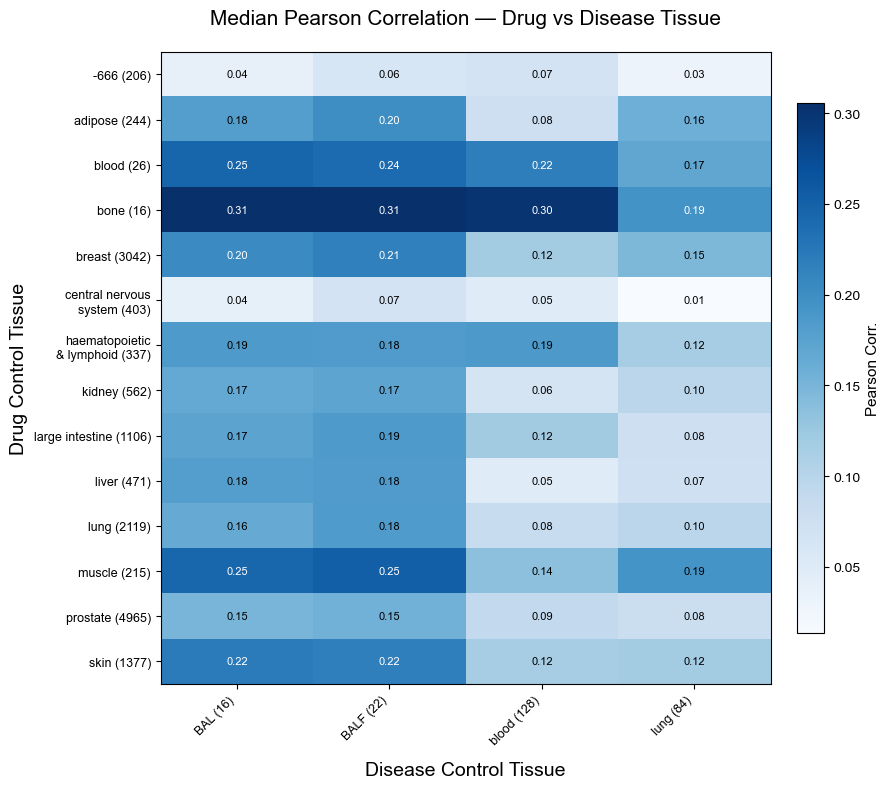

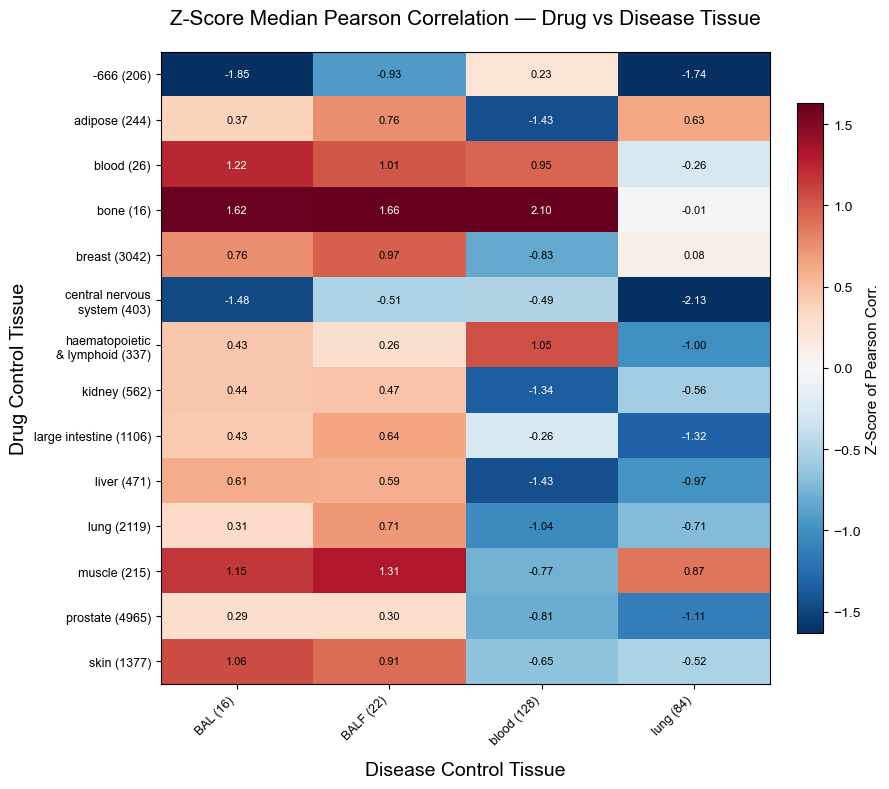

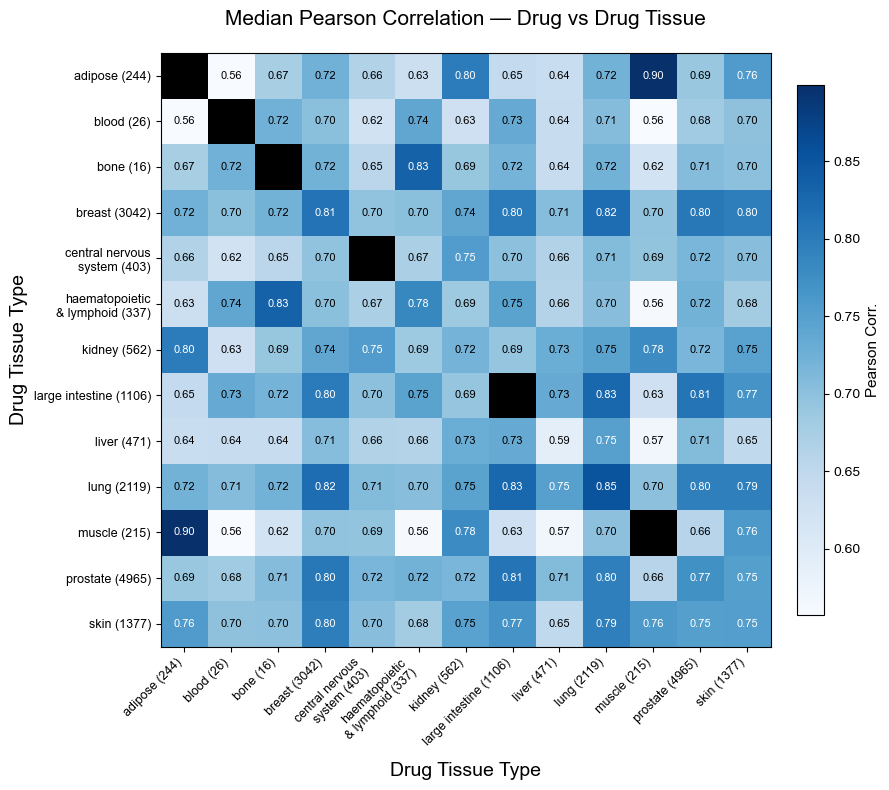

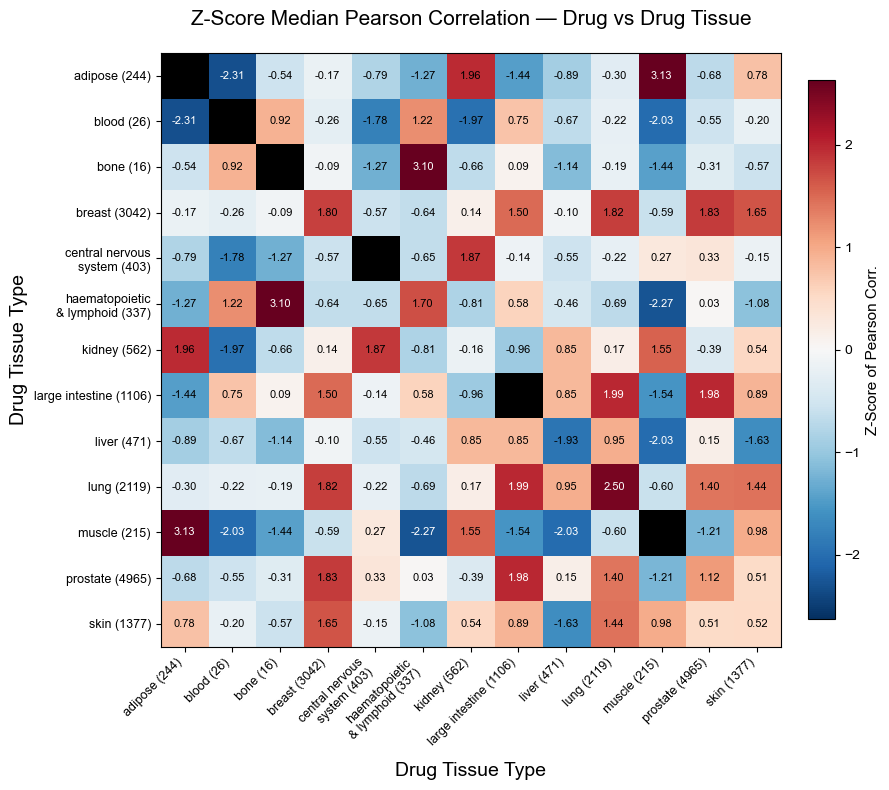

In [3]:
# Build tissue-level matrices and plot 

# — Drug × Disease —
for ctype in CORRELATION_TYPES:
    tm = build_tissue_matrix(
        drug_dis_corrs[ctype],
        row_groups=drug_tissue_groups,
        col_groups=disease_tissue_groups,
        mask_diagonal=False,
    )
    xlabels = make_axis_labels(disease_tissues, disease_tissue_groups, DIS_TISSUE_NAME_MAP)
    ylabels = make_axis_labels(drug_tissues,    drug_tissue_groups,    DRUG_TISSUE_NAME_MAP,
                               count_source=drug_tissue_sample_counts)

    plot_tissue_heatmaps(
        tm, xlabels, ylabels,
        title_prefix='Drug vs Disease Tissue',
        xlabel='Disease Control Tissue',
        ylabel='Drug Control Tissue',
    )

# — Drug × Drug —
for ctype in CORRELATION_TYPES:
    tm = build_tissue_matrix(
        drug_drug_corrs[ctype],
        row_groups=drug_tissue_groups,
        col_groups=drug_tissue_groups,
        mask_diagonal=True, # exclude self cell line comparison on diagonal
    )

    # Drop the first sorted tissue (lowest-count artefact, as in original code)
    tm_trimmed = tm.iloc[1:, 1:]
    tissues_trimmed = drug_tissues[1:]

    labels = make_axis_labels(tissues_trimmed, drug_tissue_groups, DRUG_TISSUE_NAME_MAP,
                              count_source=drug_tissue_sample_counts)

    plot_tissue_heatmaps(
        tm_trimmed, labels, labels,
        title_prefix='Drug vs Drug Tissue',
        xlabel='Drug Tissue Type',
        ylabel='Drug Tissue Type',
    )